# Ocean Lake sample 16S-seq (paired-end) QIIME 2 Analysis

#### by Jingjing Cheng and Xiangpeng Li

## Goal
QIIME 2 analysis: 16-seq paired-end reads.

## Raw data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_16S_rename/`
  
## Analysis Folder 
`/data10/xli/project/pama-seq/OL_16S_analysis`

# Generate manifest.tsv (paired-end)

QIIME 2 paired-end import requires a manifest with:
- sample-id
- forward-absolute-filepath
- reverse-absolute-filepath

We generate the manifest and save the file in `/data10/xli/project/pama-seq/OL_16S_analysis/`.

In [79]:
# Generate manifest.tsv (paired-end)
import os
import re

# Input and output paths
input_dir = "/data10/xli/raw_data/miseq_202512_jingjing/OL_16S_rename"
output_manifest = "/data10/xli/project/pama-seq/OL_16S_analysis/manifest.tsv"

# Regex to extract sample ID
pattern = re.compile(r"(.+)_S\d+_L001_R1_001.fastq.gz")

# Collect R1 files
r1_files = [f for f in os.listdir(input_dir) if f.endswith("_R1_001.fastq.gz")]

with open(output_manifest, "w") as out:
    # Write header
    out.write("sample-id\tforward-absolute-filepath\treverse-absolute-filepath\n")
    
    for r1 in sorted(r1_files):
        match = pattern.match(r1)
        if not match:
            continue
        
        sample_id = match.group(1)
        
        r1_path = os.path.abspath(os.path.join(input_dir, r1))
        r2 = r1.replace("_R1_", "_R2_")
        r2_path = os.path.abspath(os.path.join(input_dir, r2))
        
        if not os.path.exists(r2_path):
            print(f"Warning: Missing R2 file for {sample_id}")
            continue
        
        out.write(f"{sample_id}\t{r1_path}\t{r2_path}\n")

print(f"Manifest saved to: {output_manifest}")

Manifest saved to: /data10/xli/project/pama-seq/OL_16S_analysis/manifest.tsv


## Run Qiime2 for analysis 

## Demultiplexed read quality assessment (demux summarize)

After importing the paired-end PAMA-seq reads into QIIME 2, we summarize the
demultiplexed data to assess sequencing quality before denoising.

## DADA2 denoising and paired-end merging

After assessing read quality with `demux summarize`, we perform denoising and
paired-end merging using **DADA2**.

### Purpose
This step aims to:
- Correct sequencing errors using a learned error model
- Infer exact amplicon sequence variants (ASVs)
- Merge forward and reverse reads
- Remove chimeric sequences
- Generate a feature table and representative sequences

### Parameter choice
Truncation lengths were selected based on the quality profiles observed in
`demux-paired.qzv`:

- Forward reads (R1): truncated at **270 bp**
- Reverse reads (R2): truncated at **260 bp**

No primer or barcode trimming is applied (`trim-left = 0`) because these
sequences were already removed upstream.

### Execution strategy
DADA2 is computationally intensive.  
To avoid interruption due to network or SSH disconnection, the command is
executed as a **background batch job**.

save the following as "/data10/xli/project/pama-seq/OL_16S_analysis/qiime2_16s.sh"
and run the following command:
bash qiime2_16s.sh

# Analysis

In [80]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

In [81]:
!ls /data10/xli/project/pama-seq/OL_16S_analysis/*

/data10/xli/project/pama-seq/OL_16S_analysis/demux-paired.qza
/data10/xli/project/pama-seq/OL_16S_analysis/demux-paired.qzv
/data10/xli/project/pama-seq/OL_16S_analysis/denoising-stats.qza
/data10/xli/project/pama-seq/OL_16S_analysis/manifest.tsv
/data10/xli/project/pama-seq/OL_16S_analysis/outputOL-16S-1a_vs_OL-16S-1b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_16S_analysis/outputOL-16S-2a_vs_OL-16S-2b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_16S_analysis/outputOL-16S-3a_vs_OL-16S-3b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_16S_analysis/outputOL-16S-4a_vs_OL-16S-4b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_16S_analysis/qiime2_16s.sh
/data10/xli/project/pama-seq/OL_16S_analysis/rep-seqs.qza
/data10/xli/project/pama-seq/OL_16S_analysis/table.qza
/data10/xli/project/pama-seq/OL_16S_analysis/taxonomy.qza
/data10/xli/project/pama-seq/OL_16S_analysis/taxonomy.qzv

/data10/xli/project/pama-seq/OL_16S_analysis/exported-feature-table:
feature-table.biom  feature_tab

In [82]:
# Define working and output directories for 16S analysis
# Load taxonomy table exported from QIIME2 (taxonomy.tsv)
# Load ASV feature table with sample counts and Feature ID as index


wk_dir = "/data10/xli/project/pama-seq/OL_16S_analysis/"
out_dir = os.path.join(wk_dir, "output")
os.makedirs(out_dir, exist_ok=True)

# 1) Taxonomy (exported from the QZA file as taxonomy.tsv)
taxonomy_file = os.path.join(wk_dir, "exported-taxonomy/taxonomy.tsv")
tax = pd.read_csv(taxonomy_file, sep="\t")

# 2) ASV table (exported from the QZA file as feature-table.tsv)
table_file = os.path.join(wk_dir, 'exported-feature-table/feature_table.tsv')
asv = pd.read_csv(table_file, sep="\t", comment="#", index_col=0)

tax.head()

,Feature ID,Taxon,Confidence
0,7a67662a35c24ad02e1a9c553f695752,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999957
1,76cc4e4423fe1d58c82a861e79323bd7,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999936
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999927
3,e2fc9fa8e63d8276f399c93709e08fd5,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999945
4,c3caa6e2a48f3f2ab0b049512dc8ccda,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999943


<Axes: ylabel='Frequency'>

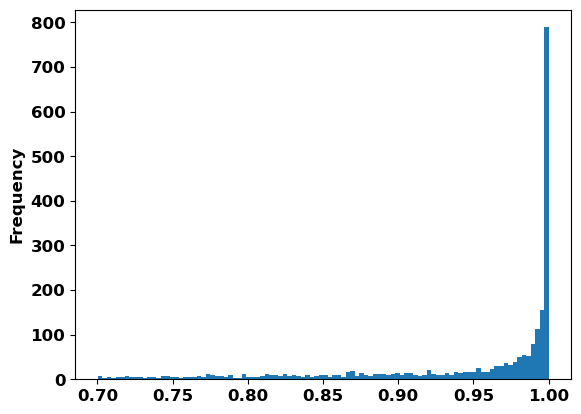

In [83]:
tax.Confidence.plot.hist(bins=100)

In [84]:
# Subset taxonomy to required columns (Feature ID, Taxon, Confidence)
# Filter features with confidence ≥ 0.90 for reliable taxonomic assignment
# Standardize column names for downstream processing

tax_qiime = tax[["Feature ID", "Taxon", "Confidence"]].copy()
tax_qiime = tax_qiime[tax_qiime["Confidence"] >= 0.90]
tax_qiime.columns = ["Feature ID", "Taxon", "Confidence"]
tax_qiime.head()

,Feature ID,Taxon,Confidence
0,7a67662a35c24ad02e1a9c553f695752,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999957
1,76cc4e4423fe1d58c82a861e79323bd7,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999936
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999927
3,e2fc9fa8e63d8276f399c93709e08fd5,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999945
4,c3caa6e2a48f3f2ab0b049512dc8ccda,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999943


<Axes: ylabel='Frequency'>

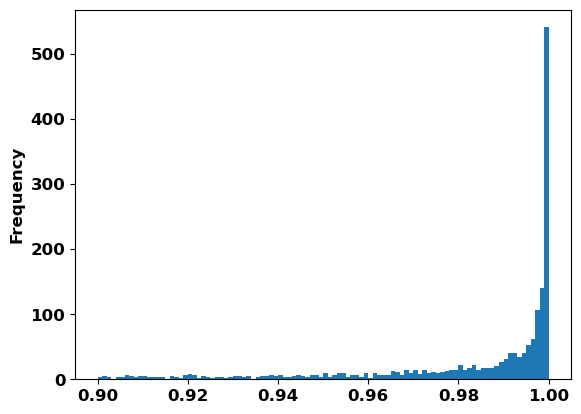

In [85]:
tax_qiime.Confidence.plot.hist(bins=100)

In [86]:
# Load 16S ASV feature table from TSV file
# Skip metadata header row to retain clean count matrix
# Preview table structure and sample count distribution

ft = pd.read_csv(wk_dir + "exported-feature-table/feature_table.tsv",
    sep="\t",
    skiprows=1
)

ft.head()

,#OTU ID,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b
0,7a67662a35c24ad02e1a9c553f695752,328.0,301.0,359.0,367.0,0.0,0.0,0.0,0.0
1,76cc4e4423fe1d58c82a861e79323bd7,317.0,276.0,369.0,369.0,0.0,0.0,0.0,0.0
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,261.0,261.0,331.0,341.0,0.0,0.0,0.0,0.0
3,e2fc9fa8e63d8276f399c93709e08fd5,231.0,283.0,308.0,305.0,0.0,0.0,0.0,0.0
4,c3caa6e2a48f3f2ab0b049512dc8ccda,245.0,274.0,305.0,291.0,0.0,0.0,0.0,0.0


In [87]:
# Set feature table index to Feature ID for consistency with taxonomy table
# Standardize index naming to ensure correct downstream alignment
# Preview indexed feature table structure

ft = ft.set_index("#OTU ID")
ft.index.name = "Feature ID"
ft.head()

,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b
Feature ID,,,,,,,,
7a67662a35c24ad02e1a9c553f695752,328.0,301.0,359.0,367.0,0.0,0.0,0.0,0.0
76cc4e4423fe1d58c82a861e79323bd7,317.0,276.0,369.0,369.0,0.0,0.0,0.0,0.0
2e06738ba1ef7e3f75f0ed55e95a2bb8,261.0,261.0,331.0,341.0,0.0,0.0,0.0,0.0
e2fc9fa8e63d8276f399c93709e08fd5,231.0,283.0,308.0,305.0,0.0,0.0,0.0,0.0
c3caa6e2a48f3f2ab0b049512dc8ccda,245.0,274.0,305.0,291.0,0.0,0.0,0.0,0.0


In [88]:
# Align taxonomy and feature table by Feature ID index
# Join taxonomy metadata (Taxon, Confidence) to ASV count table
# Remove features with zero counts across all samples
# Filter features by confidence ≥ 0.90 for reliable taxonomy


# 0) Taxonomy: make sure it contains the three columns Feature ID, Taxon, and Confidence
tax_clean = tax_qiime.copy()

# 1) Make both tables use Feature ID as index
meta_df = tax_clean.set_index("Feature ID")[["Taxon", "Confidence"]]

# 2) Feature table: make sure the index is Feature ID
taxon_df = ft.copy()
taxon_df.index.name = "Feature ID"

# 3) Join taxonomy onto counts
ol_df_with_taxon = taxon_df.join(meta_df, how="left")

# 4) Remove all-zero features
sample_cols = taxon_df.columns
ol_df_clean = ol_df_with_taxon.loc[(ol_df_with_taxon[sample_cols] != 0).any(axis=1)].copy()

conf_thresh = 0.90

ol_df_clean = ol_df_clean.loc[
    ol_df_clean["Confidence"] >= conf_thresh
].copy()

ol_df_clean.head()

,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b,Taxon,Confidence
Feature ID,,,,,,,,,,
7a67662a35c24ad02e1a9c553f695752,328.0,301.0,359.0,367.0,0.0,0.0,0.0,0.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999957
76cc4e4423fe1d58c82a861e79323bd7,317.0,276.0,369.0,369.0,0.0,0.0,0.0,0.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999936
2e06738ba1ef7e3f75f0ed55e95a2bb8,261.0,261.0,331.0,341.0,0.0,0.0,0.0,0.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999927
e2fc9fa8e63d8276f399c93709e08fd5,231.0,283.0,308.0,305.0,0.0,0.0,0.0,0.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999945
c3caa6e2a48f3f2ab0b049512dc8ccda,245.0,274.0,305.0,291.0,0.0,0.0,0.0,0.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Chloroplast;f__Chloroplast;g__Chloroplast;s__,0.999943


In [89]:
# Split taxonomy strings into standard rank levels (Kingdom to Species)
# Ensure consistent 7-level taxonomy structure by padding missing ranks
# Clean taxonomy labels by removing prefixes and trimming whitespace
# Standardize missing or unknown values as NaN for consistency


# 1) Split the taxonomy string into rank levels (Kingdom ... Species)
taxon_levels = ol_df_clean["Taxon"].astype(str).str.split(";", expand=True)

# 2) Ensure we always have exactly 7 columns (pad with NaN if taxonomy is shorter)
taxon_levels = taxon_levels.reindex(columns=range(7))

# 3) Name the columns by taxonomic rank
taxon_levels.columns = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# 4) Clean formatting: trim spaces and remove prefixes like k__, p__, c__, etc.
taxon_levels = taxon_levels.apply(
    lambda s: (
        s.astype("string")
         .str.strip()
         .str.replace(r"^[a-z]__", "", regex=True)  # remove leading rank prefix
    )
)

# 5) Standardize missing/unknown labels to NaN (optional but recommended)
taxon_levels = taxon_levels.replace({"": np.nan, "None": np.nan, "nan": np.nan, "Unassigned": np.nan})

taxon_levels.head()

,Kingdom,Phylum,Class,Order,Family,Genus,Species
Feature ID,,,,,,,
7a67662a35c24ad02e1a9c553f695752,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,<NA>
76cc4e4423fe1d58c82a861e79323bd7,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,<NA>
2e06738ba1ef7e3f75f0ed55e95a2bb8,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,<NA>
e2fc9fa8e63d8276f399c93709e08fd5,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,<NA>
c3caa6e2a48f3f2ab0b049512dc8ccda,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,<NA>


In [90]:
# 1) Combine ASV count table with parsed taxonomy levels
ol_df_final = pd.concat([ol_df_clean, taxon_levels], axis=1)

# 2) Define taxonomy columns
tax_cols = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# 3) Fill missing taxonomy labels as 'Unassigned'
ol_df_final[tax_cols] = ol_df_final[tax_cols].fillna("Unassigned")

# 3.5) Remove Chloroplast and Mitochondria

mask = ~ol_df_final["Taxon"].str.contains("Chloroplast|Mitochondria", case=False, na=False)

ol_df_final = ol_df_final[mask]
print(f"Rows after removing Chloroplast & Mitochondria: {len(ol_df_final)}")

# 4) Quick check
ol_df_final.head()

Rows after removing Chloroplast & Mitochondria: 1535


,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b,Taxon,Confidence,Kingdom,Phylum,Class,Order,Family,Genus,Species
Feature ID,,,,,,,,,,,,,,,,,
d9b68c2801789e5033af524e9579bc6c,0.0,0.0,0.0,0.0,152.0,90.0,119.0,130.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Synechococcales;f__Cyanobiaceae;g__Synechococcus_CC9902;s__,0.949806,Bacteria,Cyanobacteria,Cyanobacteriia,Synechococcales,Cyanobiaceae,Synechococcus_CC9902,Unassigned
e3a9f12464238cd45ef04be10f3221cc,0.0,0.0,0.0,0.0,132.0,76.0,122.0,111.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Synechococcales;f__Cyanobiaceae;g__Synechococcus_CC9902;s__,0.957288,Bacteria,Cyanobacteria,Cyanobacteriia,Synechococcales,Cyanobiaceae,Synechococcus_CC9902,Unassigned
6f1acc90123cbf55ff12a937e937378f,0.0,0.0,0.0,0.0,157.0,94.0,83.0,102.0,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae,0.999977,Bacteria,Proteobacteria,Alphaproteobacteria,Rhodobacterales,Rhodobacteraceae,Unassigned,Unassigned
5867104194c871f7bcbf25f8a84e01f9,0.0,0.0,0.0,0.0,129.0,63.0,103.0,108.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Synechococcales;f__Cyanobiaceae;g__Synechococcus_CC9902;s__,0.933688,Bacteria,Cyanobacteria,Cyanobacteriia,Synechococcales,Cyanobiaceae,Synechococcus_CC9902,Unassigned
615c84c753ad586852541e8d7c4a56a2,45.0,45.0,49.0,64.0,47.0,26.0,39.0,35.0,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia;o__Synechococcales;f__Cyanobiaceae;g__Cyanobium_PCC-6307;s__,0.906792,Bacteria,Cyanobacteria,Cyanobacteriia,Synechococcales,Cyanobiaceae,Cyanobium_PCC-6307,Unassigned


In [91]:
# 1) Reset index so Feature ID becomes a column
df0 = ol_df_final.reset_index().rename(columns={"#OTU ID": "Feature ID"})

# 2) Identify sample columns
sample_cols = [c for c in df0.columns if c.startswith("OL-16S-")]

# 3) Convert from wide to long format
long_df = df0.melt(
    id_vars=["Feature ID", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"],
    value_vars=sample_cols,
    var_name="SampleID",
    value_name="Count"
)

# 4) Remove zero-abundance entries
long_df = long_df.loc[long_df["Count"] > 0].copy()

# Keep a full version for stacked barplot / phylum-level analysis
long_df_all = long_df.copy()

# 5) Remove genus-level Unassigned BEFORE relative abundance
long_df = long_df.loc[long_df["Genus"] != "Unassigned"].copy()

# 5.1) Remove genus-level Uncultured
long_df = long_df.loc[~long_df["Genus"].str.contains("uncultured", case=False, na=False)].copy()
print(f"Rows after removing Uncultured genus: {len(long_df)}")

long_df.head()

Rows after removing Uncultured genus: 919


,Feature ID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count
4,615c84c753ad586852541e8d7c4a56a2,Bacteria,Cyanobacteria,Cyanobacteriia,Synechococcales,Cyanobiaceae,Cyanobium_PCC-6307,Unassigned,OL-16S-1a,45.0
6,f342c8d7070cb66e871be0c9d05ff96e,Bacteria,Proteobacteria,Alphaproteobacteria,Rhodospirillales,AEGEAN-169_marine_group,AEGEAN-169_marine_group,Unassigned,OL-16S-1a,44.0
7,1508ed417c566944af90f460dfae298c,Bacteria,Proteobacteria,Alphaproteobacteria,Rhodospirillales,AEGEAN-169_marine_group,AEGEAN-169_marine_group,Unassigned,OL-16S-1a,35.0
16,a0aa0417f7eff21c194651c53cafdb58,Bacteria,Bacteroidota,Bacteroidia,Sphingobacteriales,NS11-12_marine_group,NS11-12_marine_group,Unassigned,OL-16S-1a,75.0
25,280546b7a3ea14b1c53f066f98e8a780,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,MWH-UniP1_aquatic_group,MWH-UniP1_aquatic_group,Unassigned,OL-16S-1a,46.0


In [92]:
# 6) Pivot long back to wide (SampleID as columns)
wide_df = long_df.pivot_table(
    index=["Feature ID", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"],
    columns="SampleID",
    values="Count",
    fill_value=0
)

# Flatten column names
wide_df.columns.name = None
wide_df = wide_df.reset_index()

wide_df.head()

,Feature ID,Kingdom,Phylum,Class,Order,Family,Genus,Species,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b
0,0001573d08c69d883a9704da1c76ca56,Bacteria,Bdellovibrionota,Bdellovibrionia,Bdellovibrionales,Bdellovibrionaceae,OM27_clade,Unassigned,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0
1,001d08fe6d5575f318d37f9ad8b630a6,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Propionigenium,Unassigned,0.0,0.0,0.0,0.0,57.0,0.0,0.0,0.0
2,004b9574f6bcfda41cd195bf8f3436f8,Bacteria,Planctomycetota,Phycisphaerae,Phycisphaerales,Phycisphaeraceae,CL500-3,Unassigned,0.0,0.0,55.0,0.0,0.0,0.0,0.0,0.0
3,00ddfd3a93d9ea6458fb434ab6cc03cd,Bacteria,Hydrogenedentes,Hydrogenedentia,Hydrogenedentiales,Hydrogenedensaceae,Hydrogenedensaceae,Unassigned,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0115cfa1cec519098806a78c91581bf8,Bacteria,Calditrichota,Calditrichia,Calditrichales,Calditrichaceae,Calditrichaceae,Unassigned,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0


In [93]:
import pandas as pd

# Genus table: sum counts per SampleID × Genus
genus_table_16s = (
    long_df
    .groupby(["SampleID", "Genus"], as_index=False)["Count"]
    .sum()
)

# Relative abundance within each sample
genus_table_16s["RelAbundance"] = (
    genus_table_16s["Count"]
    / genus_table_16s.groupby("SampleID")["Count"].transform("sum")
)

# Genus × Sample matrix
genus_matrix_16s = genus_table_16s.pivot(
    index="Genus",
    columns="SampleID",
    values="RelAbundance"
).fillna(0)

# Sanity check (should be ~1.0 each)
genus_matrix_16s.sum()

SampleID
OL-16S-1a    1.0
OL-16S-1b    1.0
OL-16S-2a    1.0
OL-16S-2b    1.0
OL-16S-3a    1.0
OL-16S-3b    1.0
OL-16S-4a    1.0
OL-16S-4b    1.0
dtype: float64

In [94]:
# Step 1: detect 16S replicate pairs (a,b)
samples_16s = sorted([s for s in genus_matrix_16s.columns if s.startswith("OL-16S-")])

indices = sorted(set([s.split("OL-16S-")[-1][:-1] for s in samples_16s]))
pairs_16s = []
for i in indices:
    a = f"OL-16S-{i}a"
    b = f"OL-16S-{i}b"
    if (a in genus_matrix_16s.columns) and (b in genus_matrix_16s.columns):
        pairs_16s.append((a, b))

print("Detected pairs:", pairs_16s)

Detected pairs: [('OL-16S-1a', 'OL-16S-1b'), ('OL-16S-2a', 'OL-16S-2b'), ('OL-16S-3a', 'OL-16S-3b'), ('OL-16S-4a', 'OL-16S-4b')]


In [95]:
# Step 2: focus on ONE sample (OL-16S-1a vs 1b)

sample_a, sample_b = pairs_16s[0]   # first sample pair

x = genus_matrix_16s[sample_a]
y = genus_matrix_16s[sample_b]

mask = (x > 0) | (y > 0)

print("Total genera in full matrix:", len(x))
print("Genera present in this sample:", mask.sum())

Total genera in full matrix: 262
Genera present in this sample: 89


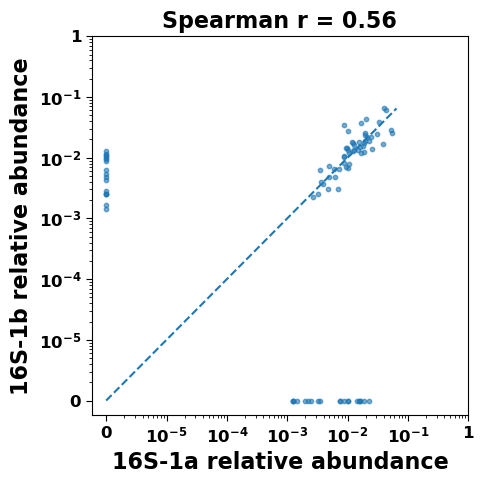

OL-16S-1a vs OL-16S-1b | genera used: 89 | Spearman r: 0.563


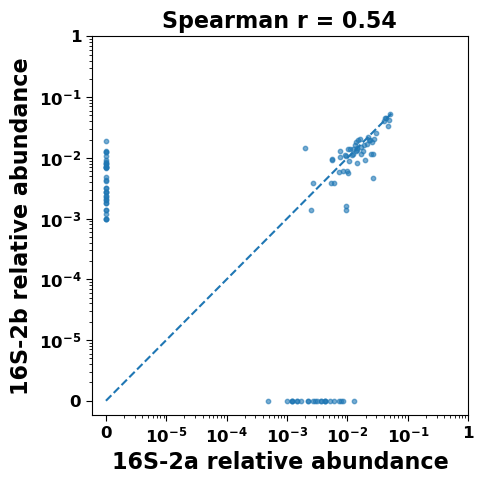

OL-16S-2a vs OL-16S-2b | genera used: 112 | Spearman r: 0.541


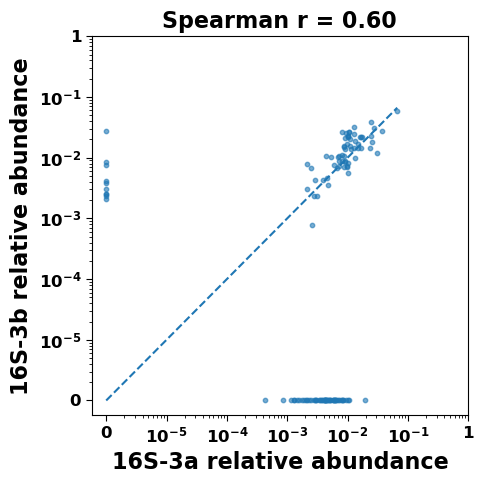

OL-16S-3a vs OL-16S-3b | genera used: 125 | Spearman r: 0.599


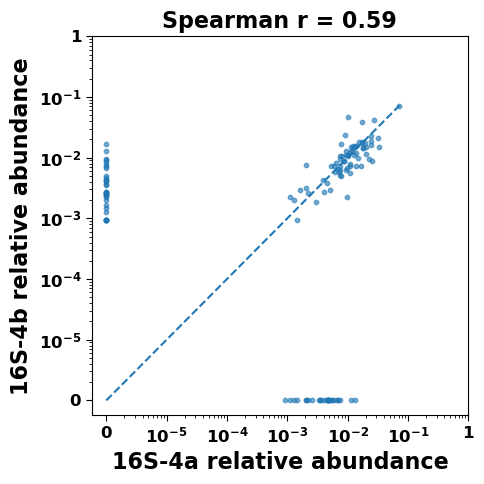

OL-16S-4a vs OL-16S-4b | genera used: 130 | Spearman r: 0.586


In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import matplotlib.ticker as ticker

pseudo = 1e-6

# =========================
# Global style (safe on Linux/HPC)
# =========================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Helvetica"]
plt.rcParams["pdf.fonttype"] = 42   # editable text in Illustrator
plt.rcParams["ps.fonttype"] = 42

# Make fonts bold-ish (optional)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Font sizes (edit here)
FS_TITLE = 16
FS_AXLABEL = 16
FS_TICK = 12
FS_LEGEND = 11
FS_LEGEND_TITLE = 12


# ---------- helper: add log-style minor ticks on a log10 axis ----------
def add_log10_minor_ticks(ax, major_ticks):
    """
    major_ticks: e.g. [-6, -5, -4, -3, -2, -1, 0]
    Adds minor tick marks at k + log10(2..9) for each decade interval.
    Works when your axis values are already log10-transformed (linear axis).
    """
    subs = np.log10(np.arange(2, 10))  # log10(2..9)
    minor = []
    for k in major_ticks[:-1]:         # between k and k+1
        minor.extend(list(k + subs))
    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor))

    # show tick marks (no labels)
    ax.tick_params(which="major", length=4, width=0.8, direction="out", labelsize=FS_TICK)
    ax.tick_params(which="minor", length=2, width=0.6, direction="out")
    # minor labels off (safety)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())


for sample_a, sample_b in pairs_16s:

    x = genus_matrix_16s[sample_a]
    y = genus_matrix_16s[sample_b]

    # sample-specific genus space
    mask = (x > 0) | (y > 0)

    x_sub = x[mask]
    y_sub = y[mask]

    rho, _ = spearmanr(x_sub, y_sub)

    x_log = np.log10(x_sub + pseudo)
    y_log = np.log10(y_sub + pseudo)

    plt.figure(figsize=(5, 5))
    plt.scatter(x_log, y_log, s=10, alpha=0.6)

    min_val = min(x_log.min(), y_log.min())
    max_val = max(x_log.max(), y_log.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ticks = [-6, -5, -4, -3, -2, -1, 0]
    labels = ["0", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$",
              r"$10^{-2}$", r"$10^{-1}$", "1"]
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)

    # ---- ADD THIS: log-style "one-bar-one-bar" minor ticks ----
    ax = plt.gca()
    add_log10_minor_ticks(ax, ticks)

    label_a = sample_a.replace("OL-", "")
    label_b = sample_b.replace("OL-", "")
    plt.xlabel(f"{label_a} relative abundance", fontsize=FS_AXLABEL)
    plt.ylabel(f"{label_b} relative abundance", fontsize=FS_AXLABEL)

    plt.title(f"Spearman r = {rho:.2f}", fontsize=FS_TITLE)

    plt.tight_layout()
    plt.savefig(out_dir + f"{sample_a}_vs_{sample_b}_shared_genus.pdf",
                bbox_inches="tight")
    plt.show()

    print(sample_a, "vs", sample_b,
          "| genera used:", len(x_sub),
          "| Spearman r:", round(rho, 3))

In [97]:
print(long_df.shape)
print(long_df_all.shape)

(919, 10)
(1668, 10)


In [98]:
# Select taxonomic rank for aggregation (e.g., Phylum)
# Sum counts per sample at the selected taxonomic level
# Normalize counts to relative abundance within each sample

rank = "Phylum"

rank_ab = (
    long_df_all.groupby(["SampleID", rank], as_index=False)["Count"]
    .sum()
)

rank_ab["RelAbundance"] = rank_ab["Count"] / rank_ab.groupby("SampleID")["Count"].transform("sum")
rank_ab.head()

,SampleID,Phylum,Count,RelAbundance
0,OL-16S-1a,Acidobacteriota,388.0,0.046826
1,OL-16S-1a,Actinobacteriota,1127.0,0.136013
2,OL-16S-1a,Armatimonadota,59.0,0.007120
3,OL-16S-1a,Bacteroidota,1087.0,0.131185
4,OL-16S-1a,Bdellovibrionota,207.0,0.024982


In [99]:
# Reshape relative abundance data into sample-by-taxon matrix
# Use selected taxonomic rank as columns and samples as rows
# Fill missing values with zero for complete matrix representation

plot_wide = rank_ab.pivot_table(
    index="SampleID",
    columns=rank,
    values="RelAbundance",
    fill_value=0
)

plot_wide.head()

Phylum,Acidobacteriota,Actinobacteriota,Armatimonadota,Bacteroidota,Bdellovibrionota,Calditrichota,Campylobacterota,Chloroflexi,Ciliophora,Cloacimonadota,Crenarchaeota,Cyanobacteria,Dependentiae,Desulfobacterota,Elusimicrobiota,Euryarchaeota,Firmicutes,Fusobacteriota,Gemmatimonadota,Hydrogenedentes,Latescibacterota,Marinimicrobia_(SAR406_clade),Methylomirabilota,Myxococcota,Nanoarchaeota,Nitrospirota,Patescibacteria,Planctomycetota,Proteobacteria,SAR324_clade(Marine_group_B),Spirochaetota,Sva0485,Thermoplasmatota,Unassigned,Verrucomicrobiota,WS2,Zixibacteria
SampleID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OL-16S-1a,0.046826,0.136013,0.007120,0.131185,0.024982,0.000000,0.000000,0.010017,0.002293,0.00000,0.000000,0.030533,0.000000,0.005189,0.000000,0.000000,0.000000,0.001931,0.010017,0.000000,0.000000,0.002896,0.000000,0.004586,0.000000,0.009655,0.000000,0.057929,0.416727,0.009413,0.000000,0.001086,0.00000,0.050929,0.040671,0.000000,0.000000
OL-16S-1b,0.019956,0.133576,0.007429,0.153678,0.022724,0.000000,0.000000,0.007429,0.001602,0.00000,0.002622,0.013401,0.000000,0.004079,0.000000,0.000000,0.000000,0.001894,0.005098,0.000874,0.000000,0.003350,0.000000,0.003933,0.000000,0.001894,0.000000,0.110269,0.403496,0.013110,0.000000,0.000000,0.00000,0.058121,0.031464,0.000000,0.000000
OL-16S-2a,0.032988,0.117144,0.004936,0.171924,0.026005,0.000000,0.002047,0.015772,0.000000,0.00000,0.002769,0.024922,0.001324,0.013484,0.001324,0.000000,0.002047,0.002649,0.000000,0.002047,0.000000,0.002769,0.000000,0.002167,0.000000,0.006622,0.000843,0.097881,0.385264,0.000963,0.000000,0.000000,0.00000,0.037202,0.044907,0.000000,0.000000
OL-16S-2b,0.037792,0.106802,0.007011,0.151714,0.030891,0.000000,0.000000,0.008106,0.000000,0.00000,0.001534,0.030562,0.002191,0.014240,0.000000,0.001095,0.001314,0.002081,0.016431,0.000000,0.004710,0.005258,0.002629,0.004601,0.000548,0.008544,0.000000,0.091138,0.400482,0.007887,0.000767,0.001534,0.00000,0.036149,0.023989,0.000000,0.000000
OL-16S-3a,0.004172,0.030288,0.000000,0.259324,0.010013,0.002336,0.017021,0.018356,0.000000,0.00025,0.000000,0.073509,0.001418,0.030788,0.000000,0.000000,0.001168,0.004756,0.004923,0.000000,0.002503,0.000000,0.000000,0.009595,0.005006,0.000000,0.002670,0.074677,0.379141,0.007676,0.000000,0.000000,0.00242,0.010346,0.045223,0.001502,0.000918


In [100]:
# Order taxa by overall abundance
tax_order = plot_wide.sum(axis=0).sort_values(ascending=False)

# Top20, but force Unassigned into Other
top20 = [x for x in tax_order.index.tolist() if x != "Unassigned"][:20]

# Build Top20 + Other table
phylum_top = plot_wide[top20].copy()

# Everything else -> Other
# (including Unassigned and all non-top20 phyla)
other = plot_wide.drop(columns=top20, errors="ignore")
phylum_top["Other"] = other.sum(axis=1)

# Ensure each sample sums to exactly 1
phylum_top = phylum_top.div(phylum_top.sum(axis=1), axis=0)

# Put Other first
phylum_top = phylum_top[top20 + ["Other"]]

plot_df = phylum_top.copy()

print("Per-sample sums (should be 1.0):")
print(phylum_top.sum(axis=1).round(6))
phylum_top.head()

Per-sample sums (should be 1.0):
SampleID
OL-16S-1a    1.0
OL-16S-1b    1.0
OL-16S-2a    1.0
OL-16S-2b    1.0
OL-16S-3a    1.0
OL-16S-3b    1.0
OL-16S-4a    1.0
OL-16S-4b    1.0
dtype: float64


Phylum,Proteobacteria,Bacteroidota,Planctomycetota,Actinobacteriota,Cyanobacteria,Verrucomicrobiota,Acidobacteriota,Desulfobacterota,Bdellovibrionota,Campylobacterota,Chloroflexi,Myxococcota,SAR324_clade(Marine_group_B),Gemmatimonadota,Nanoarchaeota,Nitrospirota,Armatimonadota,Latescibacterota,Fusobacteriota,Marinimicrobia_(SAR406_clade),Other
SampleID,,,,,,,,,,,,,,,,,,,,,
OL-16S-1a,0.416727,0.131185,0.057929,0.136013,0.030533,0.040671,0.046826,0.005189,0.024982,0.000000,0.010017,0.004586,0.009413,0.010017,0.000000,0.009655,0.007120,0.000000,0.001931,0.002896,0.054308
OL-16S-1b,0.403496,0.153678,0.110269,0.133576,0.013401,0.031464,0.019956,0.004079,0.022724,0.000000,0.007429,0.003933,0.013110,0.005098,0.000000,0.001894,0.007429,0.000000,0.001894,0.003350,0.063219
OL-16S-2a,0.385264,0.171924,0.097881,0.117144,0.024922,0.044907,0.032988,0.013484,0.026005,0.002047,0.015772,0.002167,0.000963,0.000000,0.000000,0.006622,0.004936,0.000000,0.002649,0.002769,0.047556
OL-16S-2b,0.400482,0.151714,0.091138,0.106802,0.030562,0.023989,0.037792,0.014240,0.030891,0.000000,0.008106,0.004601,0.007887,0.016431,0.000548,0.008544,0.007011,0.004710,0.002081,0.005258,0.047212
OL-16S-3a,0.379141,0.259324,0.074677,0.030288,0.073509,0.045223,0.004172,0.030788,0.010013,0.017021,0.018356,0.009595,0.007676,0.004923,0.005006,0.000000,0.000000,0.002503,0.004756,0.000000,0.023029


In [101]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

phylum_top_display = phylum_top.T
phylum_top_display

SampleID,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b
Phylum,,,,,,,,
Proteobacteria,0.416727,0.403496,0.385264,0.400482,0.379141,0.404489,0.340029,0.328228
Bacteroidota,0.131185,0.153678,0.171924,0.151714,0.259324,0.248588,0.270552,0.268381
Planctomycetota,0.057929,0.110269,0.097881,0.091138,0.074677,0.073752,0.071672,0.068490
Actinobacteriota,0.136013,0.133576,0.117144,0.106802,0.030288,0.035731,0.036769,0.033042
Cyanobacteria,0.030533,0.013401,0.024922,0.030562,0.073509,0.064743,0.068269,0.081072
Verrucomicrobiota,0.040671,0.031464,0.044907,0.023989,0.045223,0.066728,0.048842,0.053282
Acidobacteriota,0.046826,0.019956,0.032988,0.037792,0.004172,0.004275,0.010646,0.015755
Desulfobacterota,0.005189,0.004079,0.013484,0.014240,0.030788,0.023362,0.038744,0.038840
Bdellovibrionota,0.024982,0.022724,0.026005,0.030891,0.010013,0.002749,0.007024,0.016630


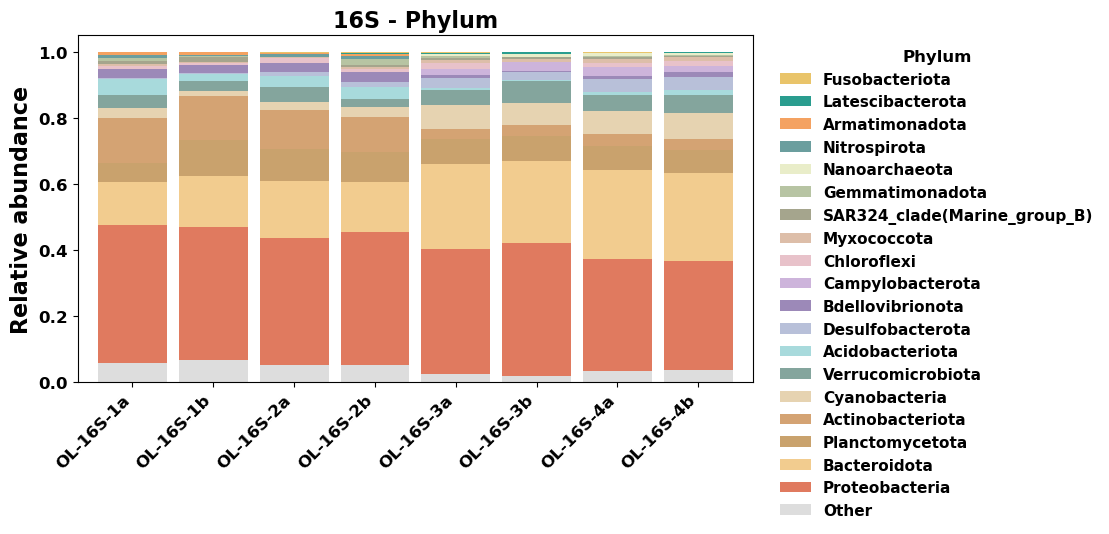

Done. PDFs saved to: /data10/xli/project/pama-seq/OL_16S_analysis/output


In [102]:
import os
import matplotlib.pyplot as plt

# Global style (safe on Linux/HPC)
# =========================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Helvetica"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"



# Parameters
# =========================
levels = ["Phylum"]
top_n = 20

FS_TITLE = 16
FS_AXLABEL = 16
FS_TICK = 12
FS_LEGEND = 11
FS_LEGEND_TITLE = 12

extended_palette = [
    "#E07A5F", "#F2CC8F", "#C9A26D", "#D4A373", "#E6D3B1",
    "#84A59D", "#A8DADC", "#B8C0D9", "#9C89B8", "#CDB4DB",
    "#E8C2CA", "#DDBEA9", "#A5A58D", "#B7C4A3", "#E9EDC9",
    "#6B9E9E", "#F4A261", "#2A9D8F", "#E9C46A", "#457B9D",
    "#1D3557",
]


def sample_key(s):
    tail = s.split("-")[-1]
    return (int(tail[0]), tail[1])

for rank in levels:

    # 1) Sum counts per Sample × Taxon
    df = (
        long_df_all
        .groupby([rank, "SampleID"])["Count"]
        .sum()
        .reset_index()
    )

    # 2) Convert to relative abundance
    df["RelAbundance"] = df["Count"] / df.groupby("SampleID")["Count"].transform("sum")

    # 3) Wide table
    wide = df.pivot_table(
        index="SampleID",
        columns=rank,
        values="RelAbundance",
        fill_value=0
    )

    # ---- sort ----
    sample_order = sorted(wide.index.tolist(), key=sample_key)
    wide = wide.reindex(sample_order)

    # 4) Order taxa by overall abundance
    tax_order = wide.sum(axis=0).sort_values(ascending=False)

    # 5) Top N + threshold
    keep = tax_order.head(top_n).index.tolist() 
    keep = [k for k in keep if k != "Unassigned"]

    plot_df = wide[keep].copy()
    plot_df["Other"] = wide.drop(columns=keep, errors="ignore").sum(axis=1)

    ordered_cols = ["Other"] + (
        plot_df.drop(columns="Other").sum().sort_values(ascending=False).index.tolist()
    )
    plot_df = plot_df[ordered_cols]

    # 6) 
    n_taxa = len(ordered_cols) - 1
    colors = ["#DDDDDD"] + extended_palette[:n_taxa]

    # 7) Plot
    fig, ax = plt.subplots(figsize=(10, 4.5))
    plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.85, color=colors)

    ax.set_ylabel("Relative abundance", fontsize=FS_AXLABEL)
    ax.set_xlabel("")
    ax.set_title(f"16S - {rank}", fontsize=FS_TITLE)

    ax.set_xticklabels(plot_df.index.tolist(), rotation=45, ha="right", fontsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1], labels[::-1],
        title=rank,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=FS_LEGEND,
        title_fontsize=FS_LEGEND_TITLE
    )

    plt.subplots_adjust(right=0.80)

    out_fp = os.path.join(out_dir, f"16S_{rank}_top{top_n}.pdf")
    plt.savefig(out_fp, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Done. PDFs saved to:", out_dir)

PCoA input shape: (8, 262)
Sample sums (should be close to 1.0):
SampleID
OL-16S-1a    1.0
OL-16S-1b    1.0
OL-16S-2a    1.0
OL-16S-2b    1.0
OL-16S-3a    1.0
OL-16S-3b    1.0
OL-16S-4a    1.0
OL-16S-4b    1.0
dtype: float64
    SampleID  Group Replicate ShortLabel
0  OL-16S-1a  River         a         1a
1  OL-16S-1b  River         b         1b
2  OL-16S-2a  River         a         2a
3  OL-16S-2b  River         b         2b
4  OL-16S-3a  Ocean         a         3a
5  OL-16S-3b  Ocean         b         3b
6  OL-16S-4a  Ocean         a         4a
7  OL-16S-4b  Ocean         b         4b

Bray-Curtis distance matrix:
SampleID   OL-16S-1a  OL-16S-1b  OL-16S-2a  OL-16S-2b  OL-16S-3a  OL-16S-3b  \
SampleID                                                                      
OL-16S-1a     0.0000     0.2979     0.2664     0.2617     0.8109     0.8268   
OL-16S-1b     0.2979     0.0000     0.3040     0.3104     0.8298     0.8252   
OL-16S-2a     0.2664     0.3040     0.0000     0.2590     0.

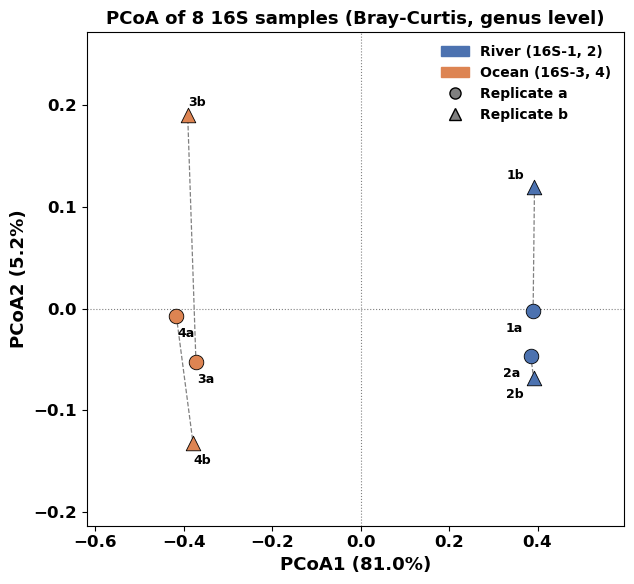

In [103]:
# Classical PCoA on all 8 16S samples
# Bray-Curtis distance + exact eigen decomposition
# Replicate a/b distinguished by marker shape, connected by dashed lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from matplotlib.lines import Line2D

# =========================
# 1. Prepare sample-by-genus matrix
# =========================
pcoa_input = genus_matrix_16s.T.copy()
print("PCoA input shape:", pcoa_input.shape)
print("Sample sums (should be close to 1.0):")
print(pcoa_input.sum(axis=1).round(4))

# =========================
# 2. Metadata
# =========================
metadata = pd.DataFrame({"SampleID": pcoa_input.index.tolist()})

metadata["Group"] = metadata["SampleID"].map({
    "OL-16S-1a": "River", "OL-16S-1b": "River",
    "OL-16S-2a": "River", "OL-16S-2b": "River",
    "OL-16S-3a": "Ocean", "OL-16S-3b": "Ocean",
    "OL-16S-4a": "Ocean", "OL-16S-4b": "Ocean",
})
metadata["Replicate"] = metadata["SampleID"].apply(
    lambda x: "a" if x.endswith("a") else "b"
)
metadata["ShortLabel"] = metadata["SampleID"].str.replace("OL-16S-", "", regex=False)
print(metadata)

# =========================
# 3. Bray-Curtis distance matrix
# =========================
D = squareform(pdist(pcoa_input.values, metric="braycurtis"))
dist_df = pd.DataFrame(D, index=pcoa_input.index, columns=pcoa_input.index)
print("\nBray-Curtis distance matrix:")
print(dist_df.round(4))

# =========================
# 4. Classical PCoA (exact eigen decomposition)
# =========================
n = D.shape[0]

# Double-centering
H = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * H @ (D ** 2) @ H

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(B)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Keep only positive eigenvalues
positive = eigvals > 0
eigvals_pos = eigvals[positive]
eigvecs_pos = eigvecs[:, positive]

# PCoA coordinates (first two axes)
coords = eigvecs_pos[:, :2] * np.sqrt(eigvals_pos[:2])

# Explained variance
var_explained = eigvals_pos / eigvals_pos.sum()
pc1_pct = var_explained[0] * 100
pc2_pct = var_explained[1] * 100
print(f"\nPCoA1: {pc1_pct:.1f}%")
print(f"PCoA2: {pc2_pct:.1f}%")

# =========================
# 5. Build coordinate DataFrame
# =========================
pcoa_df = pd.DataFrame(
    coords, columns=["PCoA1", "PCoA2"],
    index=pcoa_input.index
).reset_index().rename(columns={"index": "SampleID"})
pcoa_df = pcoa_df.merge(metadata, on="SampleID", how="left")
print(pcoa_df)

# =========================
# 6. Plot
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "Helvetica"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "font.size": 12,
})

group_colors  = {"River": "#4C72B0", "Ocean": "#DD8452"}
rep_markers   = {"a": "o", "b": "^"}   # circle = replicate a, triangle = replicate b

# --- compute axis limits with padding BEFORE plotting ---
x_pad = (pcoa_df["PCoA1"].max() - pcoa_df["PCoA1"].min()) * 0.25
y_pad = (pcoa_df["PCoA2"].max() - pcoa_df["PCoA2"].min()) * 0.25
xlim = (pcoa_df["PCoA1"].min() - x_pad, pcoa_df["PCoA1"].max() + x_pad)
ylim = (pcoa_df["PCoA2"].min() - y_pad, pcoa_df["PCoA2"].max() + y_pad)

fig, ax = plt.subplots(figsize=(6.5, 6.0))

# -- scatter points --
for _, row in pcoa_df.iterrows():
    ax.scatter(
        row["PCoA1"], row["PCoA2"],
        s=110,
        color=group_colors[row["Group"]],
        marker=rep_markers[row["Replicate"]],
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

# -- dashed lines connecting replicate a/b pairs --
replicate_pairs = [
    ("OL-16S-1a", "OL-16S-1b"),
    ("OL-16S-2a", "OL-16S-2b"),
    ("OL-16S-3a", "OL-16S-3b"),
    ("OL-16S-4a", "OL-16S-4b"),
]
for sa, sb in replicate_pairs:
    xa, ya = pcoa_df.loc[pcoa_df["SampleID"] == sa, ["PCoA1", "PCoA2"]].values[0]
    xb, yb = pcoa_df.loc[pcoa_df["SampleID"] == sb, ["PCoA1", "PCoA2"]].values[0]
    ax.plot([xa, xb], [ya, yb], color="gray", lw=0.9, ls="--", zorder=1)

# -- sample labels: smart offset to avoid going outside plot --
x_range = xlim[1] - xlim[0]
y_range = ylim[1] - ylim[0]
x_mid   = (xlim[0] + xlim[1]) / 2
y_mid   = (ylim[0] + ylim[1]) / 2

for _, row in pcoa_df.iterrows():
    # shift label away from the nearest axis edge
    dx = -0.035 * x_range if row["PCoA1"] > x_mid else 0.018 * x_range
    dy =  0.025 * y_range if row["PCoA2"] > y_mid else -0.035 * y_range
    ax.text(
        row["PCoA1"] + dx,
        row["PCoA2"] + dy,
        row["ShortLabel"],
        fontsize=9,
        ha="center", va="center",
    )

# -- reference lines --
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(f"PCoA1 ({pc1_pct:.1f}%)", fontsize=13)
ax.set_ylabel(f"PCoA2 ({pc2_pct:.1f}%)", fontsize=13)
ax.set_title("PCoA of 8 16S samples (Bray-Curtis, genus level)", fontsize=13)

# -- legend --
legend_handles = [
    mpatches.Patch(color=group_colors["River"], label="River (16S-1, 2)"),
    mpatches.Patch(color=group_colors["Ocean"], label="Ocean (16S-3, 4)"),
    Line2D([0], [0], marker="o", color="gray", label="Replicate a",
           markerfacecolor="gray", markeredgecolor="black", markersize=8, linestyle="None"),
    Line2D([0], [0], marker="^", color="gray", label="Replicate b",
           markerfacecolor="gray", markeredgecolor="black", markersize=8, linestyle="None"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10, loc="best")

plt.tight_layout()
plt.savefig(out_dir + "16S_PCoA_braycurtis_final.pdf", bbox_inches="tight")
plt.show()

# =========================
# 7. Export tables
# =========================
dist_df.to_csv(out_dir +"16s_pcoa_braycurtis_distance_matrix_8samples.csv")
pcoa_df.to_csv(out_dir +"16s_pcoa_coordinates_8samples.csv", index=False)

In [104]:
out_dir

'/data10/xli/project/pama-seq/OL_16S_analysis/output'

In [105]:
genus_matrix_16s.to_csv(out_dir + "16S_genus_matrix.csv")
phylum_top.to_csv(out_dir + "16S_phylum_relative_abundance_top20.csv")